In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec

from TrackUtil import (
    get_tc_basin,
    load_ibtracs_genesis_density,
    IBTrACSAnalyzer
)

In [2]:
class TCMetricPlotter:
    def __init__(self, data_dir, experiments, syear, eyear, binsize="bin5x5",
                 obs_label="IBTrACS", label_map=None):
        self.data_dir = data_dir
        self.experiments = experiments
        self.syear = syear
        self.eyear = eyear
        self.binsize = binsize
        self.obs_label = obs_label
        self.metric_data = {}
        self.metric = None
        self.label_map = label_map or {}

    def normalize_lon(self, lon):
        if isinstance(lon, (list, tuple)):
            lon = np.array(lon)
        if hasattr(lon, "values"):
            lon_vals = lon.values
        else:
            lon_vals = lon
        return np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    def get_and_normalize_longitude(self, ds):
        possible_lon_names = ['lon', 'longitude', 'LONG', 'x']
        for lon_name in possible_lon_names:
            if lon_name in ds.coords:
                norm_lon = self.normalize_lon(ds[lon_name])
                ds = ds.assign_coords({lon_name: norm_lon})
                ds = ds.sortby(lon_name)
                if lon_name != 'lon':
                    ds = ds.rename({lon_name: 'lon'})
                return ds
        print("[WARN] No recognized longitude coordinate found.")
        return ds

    def compute_pattern_corr_exclude_zeros(self, da1, da2):
        arr1 = da1.values.flatten()
        arr2 = da2.values.flatten()
        valid_mask = np.isfinite(arr1) & np.isfinite(arr2) & (arr1 != 0)
        if np.sum(valid_mask) < 2:
            return np.nan
        return pearsonr(arr1[valid_mask], arr2[valid_mask])[0]

    def load_and_compute_climatology(self, metric="track_density"):
        self.metric = metric
        all_labels = ([self.obs_label] if self.obs_label is not None else []) + list(self.experiments)
        for label in all_labels:
            yearly_data = []
            for year in range(self.syear, self.eyear + 1):
                if label == self.obs_label and label != 'ERA5':
                    fname = f"tc_metrics_{label}_{year}_{self.binsize}.nc"
                    varname = metric
                else:
                    if self.metric == "track_density":
                        fname = f"{label}_set1_TCS_histg_full_{year}.nc"
                        varname = "trkdens"
                    elif self.metric == "genesis_density":
                        fname = f"{label}_set1_TCS_histg_genesis_{year}.nc"
                        varname = "trkdens"
                    elif self.metric == "lysis_density":
                        fname = f"{label}_set1_TCS_histg_lyses_{year}.nc"
                        varname = "trkdens"
                    else:
                        print(f"[WARN] Unsupported metric: {self.metric}")
                        continue

                fpath = os.path.join(self.data_dir, label, fname)
                if not os.path.exists(fpath):
                    print(f"[WARN] Missing file: {fpath}")
                    continue
                    
                try:
                    ds = xr.open_dataset(fpath)
                except Exception as e:
                    print(f"[ERROR] Could not open {fpath}: {e}")
                    continue

                ds = self.get_and_normalize_longitude(ds)
                if varname not in ds:
                    print(f"[WARN] Variable '{varname}' not in file: {fname}")
                    continue

                data = ds[varname].sum(dim="time") if "time" in ds[varname].dims else ds[varname]
                yearly_data.append(data)

            if yearly_data:
                stacked = xr.concat(yearly_data, dim="year")
                stacked.mean(dim="year") 
                #climatology = stacked.sum(dim="year") if self.metric in ["genesis_density", "lysis_density"] else stacked.mean(dim="year")
                climatology = stacked.mean(dim="year")
                print(f"[INFO] Loaded {len(yearly_data)} years for {label}")
                self.metric_data[label] = climatology
            else:
                print(f"[WARN] No valid data for {label}")
                self.metric_data[label] = yearly_data
            

    def plot(self, cmap="hot_r", vmin=None, vmax=None, clevels=None, cticks=None,
             figsize=(14, 12), save_path=None, fontz=14,
             hspace = 0.1, wspace=0.1):
        
        exp_labels = list(self.experiments[:4])
        fig = plt.figure(figsize=figsize)

        # Simulate custom row spacing via height_ratios
        spec = gridspec.GridSpec(
            nrows=4, ncols=2,
            height_ratios=[0.05, 0.85, 0.9, 1.0],  # spacer, ERA5, model row 1, model row 2
            width_ratios=[1, 1],
            hspace=hspace,   # small global spacing between all
            wspace=wspace
        )

        axs = []

        # Row 0: Spacer (invisible)
        fig.add_subplot(spec[0, 0]).axis("off")
        fig.add_subplot(spec[0, 1]).axis("off")

        # Row 1: ERA5 centered
        if self.obs_label not in self.metric_data:
            print(f"[WARN] Observation label '{self.obs_label}' not found in metric_data.")
            return
        
        ax_obs = fig.add_subplot(spec[1, :], projection=ccrs.PlateCarree())
        axs.append(('obs', self.obs_label, ax_obs))

        # Rows 2–3: Model experiments (2 per row)
        for idx, label in enumerate(exp_labels):
            row = 2 + idx // 2
            col = idx % 2
            ax = fig.add_subplot(spec[row, col], projection=ccrs.PlateCarree())
            axs.append(('exp', label, ax))

        # === Color normalization ===
        norm = BoundaryNorm(clevels, ncolors=plt.get_cmap(cmap).N, extend='both') if clevels else None

        mesh = None
        for i, (ptype, label, ax) in enumerate(axs):
            if label not in self.metric_data:
                print(f"[SKIP] {label} not found in metric_data.")
                ax.axis('off')
                continue

            data = self.metric_data[label]
            lon, lat = data.lon, data.lat

            ax.set_extent([-180, 180, -60, 60], crs=ccrs.PlateCarree())
            ax.coastlines()
            gl = ax.gridlines(draw_labels=True, linewidth=0.2, linestyle='--', alpha=0.6)
            gl.xlabel_style = {'size': fontz - 2}
            gl.ylabel_style = {'size': fontz - 2}
            gl.top_labels = False
            gl.right_labels = False

            mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                                 cmap=cmap, norm=norm if norm else None,
                                 vmin=vmin, vmax=vmax, shading="auto")

            pretty = self.label_map.get(label, label)
            ax.set_title(f"({chr(97 + i)}) {pretty}", fontsize=fontz, loc="left")

            # PCC only for experiments
            if ptype == 'exp' and self.obs_label in self.metric_data:
                ref = self.metric_data[self.obs_label]
                if ref.shape == data.shape:
                    corr = self.compute_pattern_corr_exclude_zeros(ref, data)
                    corr_str = f"PCC: {corr:.2f}" if not np.isnan(corr) else "PCC: NA"
                else:
                    corr_str = "PCC: NA"
                if self.metric not in ["genesis_density", "lysis_density"]:
                    ax.text(0.98, 1.02, corr_str,
                            transform=ax.transAxes, fontsize=fontz - 2,
                            ha='right', va='bottom',
                            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        if mesh:
            cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.45])
            cbar = fig.colorbar(mesh, cax=cbar_ax, orientation="vertical")
            if cticks:
                cbar.set_ticks(cticks)
            elif clevels:
                midpoints = [(clevels[i] + clevels[i + 1]) / 2 for i in range(len(clevels) - 1)]
                cbar.set_ticks(midpoints)
            cbar.ax.tick_params(labelsize=fontz - 2)
            unit_label = "per year" #if self.metric == "track_density" else "total count"
            
            cbar.set_label(f"{self.metric.replace('_', ' ').title()} ({unit_label})", fontsize=fontz)

        if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight')
            print(f"[SAVED] {save_path}")
        plt.show()
        plt.close()

[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for CLIM
[INFO] Loaded 10 years for NDGUV
[INFO] Loaded 10 years for NDGUVT
[INFO] Loaded 10 years for NDGUVTQ_SRF1
[SAVED] ./Figure_07.pdf


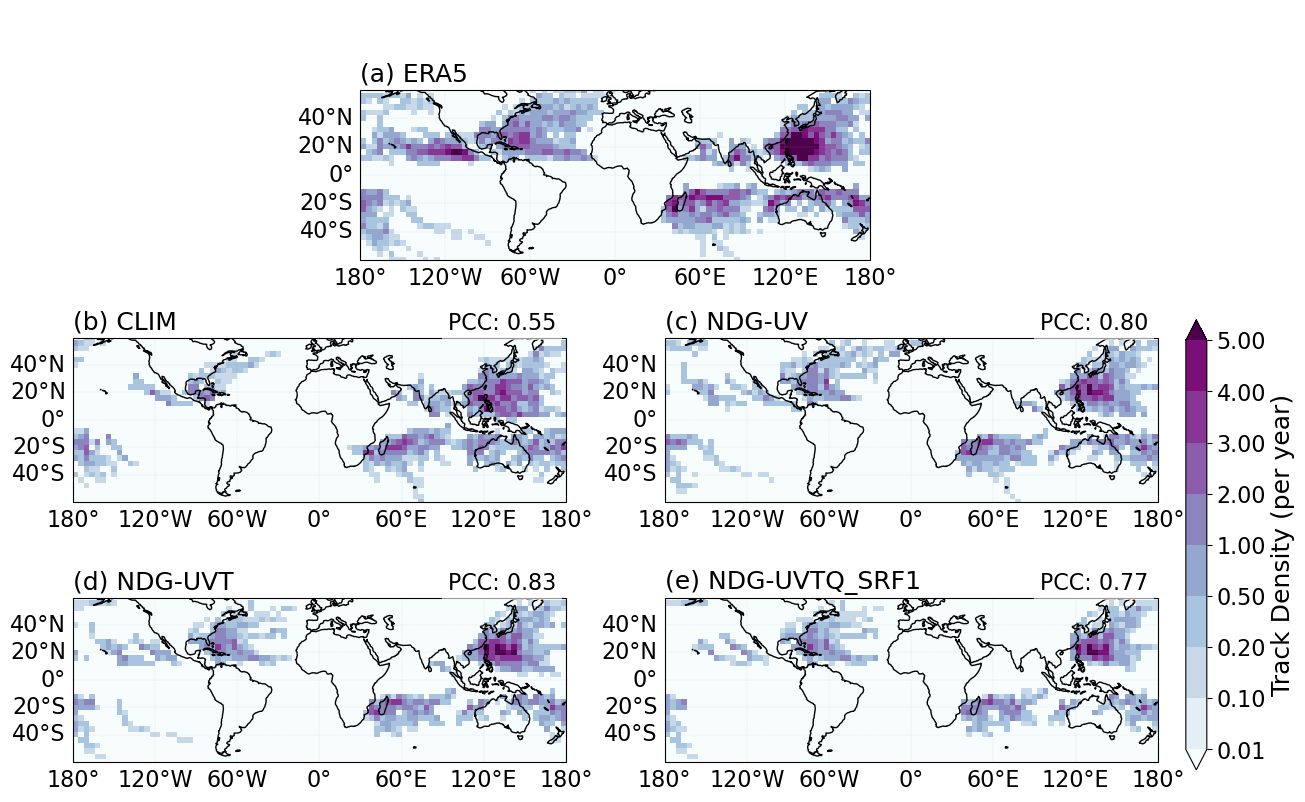

In [3]:
if __name__ == "__main__":
    # === Paths ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/TCS/trk_fnl"
    ibtracs_path = f"{top_path}/post_data/TempestExtremes/TCS/OBS/tc_track/IBTrACS/IBTrACS.ALL.v04r00.nc"
    
    out_path = os.path.join(data_path, "IBTrACS")
    os.makedirs(out_path, exist_ok=True)
    
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    # === Time Range & Binning ===
    syear, eyear = 2008, 2017
    bin_size = (4.0, 4.0)
    bin_string = f"bin{int(bin_size[0])}x{int(bin_size[1])}"

    # === Generate IBTrACS if Needed ===
    clim_file = os.path.join(out_path, f"IBTrACS_climatology_{syear}-{eyear}_{bin_string}.nc")
    if not os.path.exists(clim_file):
        print("\n[STEP 1] Initializing IBTrACS Analyzer...")
        analyzer = IBTrACSAnalyzer(ibtracs_path=ibtracs_path, syear=syear, eyear=eyear)

        print("[STEP 2] Loading and filtering IBTrACS...")
        ibtracs_df = analyzer.load_and_filter_ibtracs()

        print("[STEP 3] Saving yearly IBTrACS metrics...")
        analyzer.save_yearly_density(out_dir=out_path, bins=bin_size)

        print("[STEP 4] Saving climatology...")
        analyzer.save_multiyear_climatology(metric_dir=out_path, out_file=clim_file, bins=bin_size)
        print("\n[DONE] IBTrACS metrics generated and saved.")

    # === All Experiments (including ERA5) ===
    exp_dict = {
        "ERA5": "ERA5",
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        # "NDGUVTQ": "NDG-UVTQ",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }

    obs_label = "ERA5"  # Use as reference and top panel

    # Pass ALL experiments including ERA5 for loading/processing
    all_experiments = list(exp_dict.keys())

    # === Initialize Plotter ===
    plotter = TCMetricPlotter(
        data_dir=data_path,
        experiments=all_experiments,     # Load everything (including ERA5)
        syear=syear,
        eyear=eyear,
        binsize=bin_string,
        obs_label=obs_label,
        label_map=exp_dict
    )

    # === Load Climatology ===
    plotter.load_and_compute_climatology(metric="track_density")

    # === Manually exclude ERA5 from experiments for plotting lower grid ===
    plotter.experiments = [exp for exp in all_experiments if exp != obs_label]

    # === Plot ===
    clevels = [0.01, 0.1, 0.2, 0.5, 1, 2, 3, 4, 5]
    cticks  = [0.01, 0.1, 0.2, 0.5, 1, 2, 3, 4, 5]

    #fig_name = "tc_track_density_climatology.pdf"
    fig_name = "Figure_07.pdf"
    plotter.plot(
        cmap="BuPu",
        clevels=clevels,
        cticks=cticks,
        figsize=(14, 10),
        fontz=18,
        hspace=0.5,
        wspace=0.2,
        save_path=os.path.join(fig_path, fig_name)
    )


[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for CLIM
[INFO] Loaded 10 years for NDGUV
[INFO] Loaded 10 years for NDGUVT
[INFO] Loaded 10 years for NDGUVTQ_SRF1
[SAVED] ./tc_genesis_density_climatology.pdf


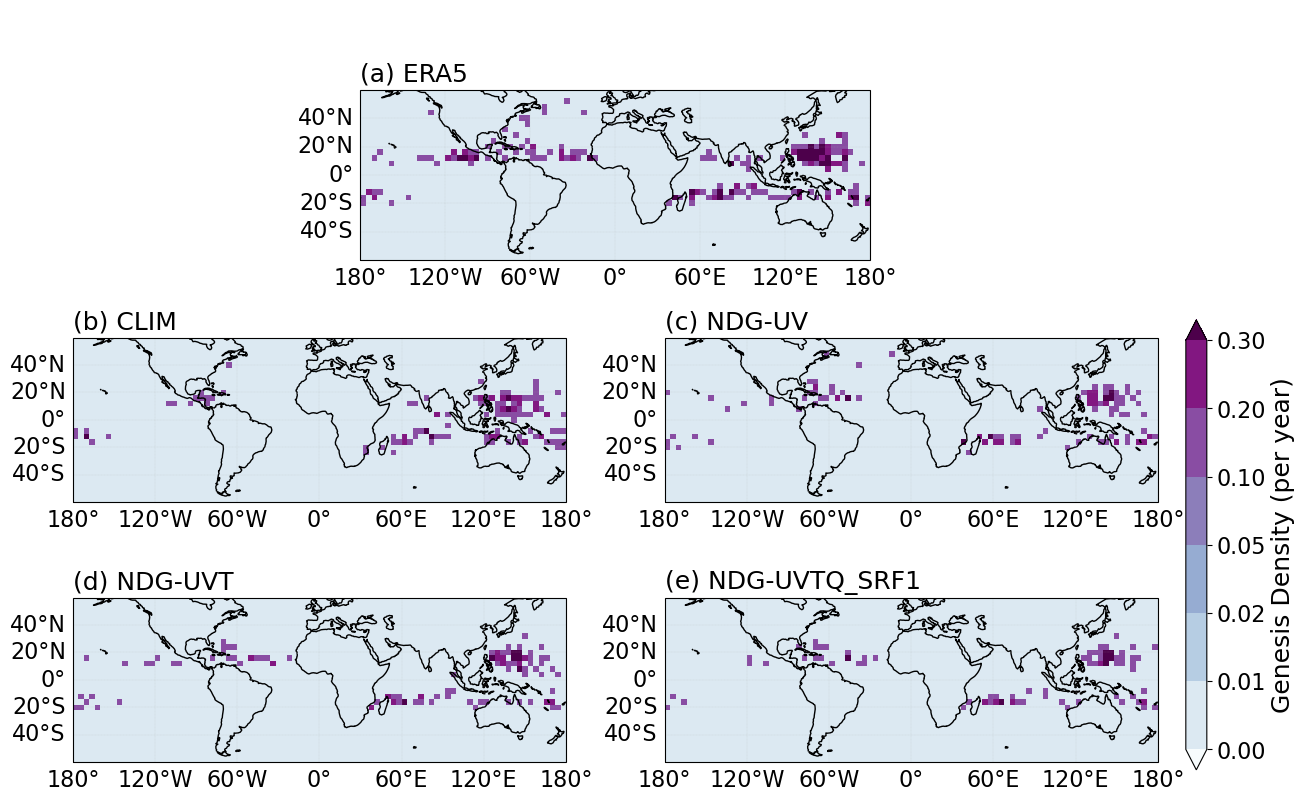

In [4]:
if __name__ == "__main__":
    # === Paths ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/TCS/trk_fnl"
    ibtracs_path = f"{top_path}/post_data/TempestExtremes/TCS/OBS/tc_track/IBTrACS/IBTrACS.ALL.v04r00.nc"
    
    out_path = os.path.join(data_path, "IBTrACS")
    os.makedirs(out_path, exist_ok=True)
    
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    # === Time Range & Binning ===
    syear, eyear = 2008, 2017
    bin_size = (4.0, 4.0)
    bin_string = f"bin{int(bin_size[0])}x{int(bin_size[1])}"

    # === Generate IBTrACS if Needed ===
    clim_file = os.path.join(out_path, f"IBTrACS_climatology_{syear}-{eyear}_{bin_string}.nc")
    if not os.path.exists(clim_file):
        print("\n[STEP 1] Initializing IBTrACS Analyzer...")
        analyzer = IBTrACSAnalyzer(ibtracs_path=ibtracs_path, syear=syear, eyear=eyear)

        print("[STEP 2] Loading and filtering IBTrACS...")
        ibtracs_df = analyzer.load_and_filter_ibtracs()

        print("[STEP 3] Saving yearly IBTrACS metrics...")
        analyzer.save_yearly_density(out_dir=out_path, bins=bin_size)

        print("[STEP 4] Saving climatology...")
        analyzer.save_multiyear_climatology(metric_dir=out_path, out_file=clim_file, bins=bin_size)
        print("\n[DONE] IBTrACS metrics generated and saved.")

    # === All Experiments (including ERA5) ===
    exp_dict = {
        "ERA5": "ERA5",
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        # "NDGUVTQ": "NDG-UVTQ",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }

    obs_label = "ERA5"  # Use as reference and top panel

    # Pass ALL experiments including ERA5 for loading/processing
    all_experiments = list(exp_dict.keys())

    # === Initialize Plotter ===
    plotter = TCMetricPlotter(
        data_dir=data_path,
        experiments=all_experiments,     # Load everything (including ERA5)
        syear=syear,
        eyear=eyear,
        binsize=bin_string,
        obs_label=obs_label,
        label_map=exp_dict
    )

    # === Load Climatology ===
    plotter.load_and_compute_climatology(metric="genesis_density")

    # === Manually exclude ERA5 from experiments for plotting lower grid ===
    plotter.experiments = [exp for exp in all_experiments if exp != obs_label]

    # === Plot ===
    clevels = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
    cticks  = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]

    #fig_name = "tc_genesis_density_climatology.pdf"
    fig_name = "Figure_07.pdf"

    plotter.plot(
        cmap="BuPu",
        clevels=clevels,
        cticks=cticks,
        figsize=(14, 10),
        fontz=18,
        hspace=0.5,
        wspace=0.2,
        save_path=os.path.join(fig_path, fig_name)
    )
